# ЛР 03.1 — Train/Validation и переобучение (Solution)

## Как проходить этот ноутбук
### Цель
- сравнить все кандидатный набор признаков (candidate feature set) на одном и том же split;
- увидеть `generalization gap` на понятных таблицах;
- выбрать набор признаков (feature set) отдельно для каждой модели;
- подготовить артефакты для второго ноутбука.

### Входные артефакты
- `../01-feature-importance-and-selection/outputs/feature_sets_wrapper_embedded.json`
- встроенные датасеты `medical` и `finance`

### Выходные артефакты
- `outputs/generalization_audit.csv`
- `outputs/model_feature_set_decisions.csv`
- `outputs/validation_curve_results.csv`

### Где находятся обязательные самостоятельные задания
- сопоставляйте этот подробный разбор с одноименными шагами и TODO-блоками в студенческом ноутбуке;
- ориентируйтесь на markdown-блоки `Как интерпретировать результат` и `Проверь себя`.

### Что потом переносится в отчет
- шаг 1: разделы `2` и `2.2`;
- шаги 2-3: разделы `2.1` и `3`;
- шаг 4: раздел `4`.

Это подробная версия разбора: читайте markdown перед кодом и сверяйте свой ход рассуждения с образцом.

In [1]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Логика для новичка: этот блок лучше читать сверху вниз как мини-сценарий шага.
# Подключаем зависимости для этого шага.
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone

cwd = Path.cwd().resolve()
candidates = [
    cwd,
    cwd.parent,
    cwd / '03-overfitting-validation-and-hyperparameter-tuning',
    cwd.parent / '03-overfitting-validation-and-hyperparameter-tuning',
]
BASE_DIR = next((path for path in candidates if (path / 'lab_utils.py').exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError(
        'Не удалось найти lab_utils.py. Откройте ноутбук из папки модуля 03 или из корня репозитория.'
    )

spec = importlib.util.spec_from_file_location('lab03_utils', BASE_DIR / 'lab_utils.py')
lab = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lab)

SEED = lab.SEED
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)
# Строим визуализацию и проверяем интерпретируемость результата.
sns.set_theme(style='whitegrid', context='talk')

## Шаг 1. Загрузка данных и кандидатный набор признаков (candidate feature set) из ЛР 01

### Что делаем
- загружаем оба датасета курса;
- читаем все кандидатный набор признаков (candidate feature set) из ЛР 01;
- один раз делим данные на `train`, `validation`, `test` в схеме `60/20/20`.

### Почему это важно
- все последующие сравнения должны идти на одном и том же split;
- кандидатный набор признаков (candidate feature set) здесь — гипотезы, а не готовые победители;
- `test` нужно зафиксировать заранее и не трогать до финала второго ноутбука.

### Что уже готово на входе
- `lab_utils.py` с загрузкой датасетов и split helper;
- upstream-артефакт `feature_sets_wrapper_embedded.json` из ЛР 01.

### Что должно получиться на выходе
- словарь `prepared` с split-контекстом по каждому dataset;
- таблица `candidate_feature_sets` со списком набор признаков (feature set) и размерами split.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [2]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Логика для новичка: этот блок лучше читать сверху вниз как мини-сценарий шага.
# Читаем данные и артефакты, с которыми будем работать дальше.
datasets = lab.load_course_datasets()
feature_sets = lab.load_feature_sets()

prepared = {}
selection_rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, df in datasets.items():
    x, y = lab.split_xy(df)
    x_train, x_valid, x_test, y_train, y_valid, y_test = lab.train_valid_test_split_stratified(x, y)
    feature_set_names = lab.list_feature_set_names(feature_sets, dataset_name)

    prepared[dataset_name] = {
        'x_train': x_train,
        'x_valid': x_valid,
        'x_test': x_test,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_test': y_test,
        'feature_set_names': feature_set_names,
    }

    selection_rows.append(
        {
            'dataset': dataset_name,
            'candidate_feature_sets': ', '.join(feature_set_names),
            'n_train': len(x_train),
            'n_validation': len(x_valid),
            'n_test': len(x_test),
        }
    )

candidate_feature_sets = pd.DataFrame(selection_rows).sort_values('dataset').reset_index(drop=True)
candidate_feature_sets

,dataset,candidate_feature_sets,n_train,n_validation,n_test
0,finance,"full, set_A_wrapper, set_B_tree, set_C_hybrid",660,220,220
1,medical,"full, set_A_wrapper, set_B_tree, set_C_hybrid",540,180,180


### Как интерпретировать результат
- Таблица `candidate_feature_sets` отвечает сразу на два вопроса: какие гипотезы по признакам пришли из ЛР 01 и как устроен текущий split `60/20/20`.
- На этом шаге мы ничего не выбираем: `test` просто фиксируется и откладывается до второго ноутбука.
- Если какой-то dataset не появился в таблице или список набор признаков (feature set) пуст, дальше идти нельзя.

### Пример вывода по шагу
- Оба датасета уже переведены в схему `train/validation/test`, поэтому все дальнейшие сравнения будут честными внутри одного и того же split.
- Candidate набор признаков (feature set) из ЛР 01 здесь рассматриваются как гипотезы, а не как готовые победители.
- В отчет из этого шага удобно перенести перечень кандидатный набор признаков и напоминание, что `test` пока не используется.

### Проверь себя
- В таблице есть оба датасета: `medical` и `finance`.
- Для каждого dataset видны `n_train`, `n_validation`, `n_test`.
- Список `candidate_feature_sets` не пустой.
- Вы можете словами объяснить, почему `test` на этом шаге только фиксируется.

## Шаг 2. Baseline-аудит по всем кандидатный набор признаков (candidate feature set)

### Что делаем
- для каждого dataset прогоняем `full` и все неполные кандидатный набор признаков (candidate feature set);
- для каждого набора признаков обучаем `LogisticRegression` и `RandomForest`;
- считаем метрики отдельно на `train` и `validation`.

### Почему это важно
- именно здесь впервые видно, где модель начинает переобучаться;
- мы сравниваем не только модели, но и представления признаков;
- базовая таблица должна стать источником для всех последующих решений в notebook 1.

### Что уже готово на входе
- `prepared` из шага 1;
- helper `PreprocessedFeatureSelector`;
- baseline-модели из `lab.make_default_models()`.

### Что должно получиться на выходе
- таблица `generalization_audit` с построчными метриками по split;
- удобная сводка `audit_overview` для чтения человеком.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [3]:
# Что делаем: Обучаем модель и, при необходимости, подбираем параметры.
# Зачем: На этом шаге формируется качество модели, которое дальше анализируется в метриках и графиках.
# Как читать результат: Смотрите на итоговые метрики и выбранные параметры: они должны соответствовать ожиданиям шага.
# Типичные ошибки: Частая ошибка — случайно обучить модель на неправильном split и получить смещенную оценку качества.

# Логика для новичка: этот блок лучше читать сверху вниз как мини-сценарий шага.
audit_rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, ctx in prepared.items():
    for feature_set_name in ctx['feature_set_names']:
        selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
        # Обучаем модель на подготовленных данных.
        selector = lab.PreprocessedFeatureSelector(selected_features=selected_features).fit(
            ctx['x_train'], ctx['y_train']
        )
        x_train_sel = selector.transform(ctx['x_train'])
        x_valid_sel = selector.transform(ctx['x_valid'])

        # Итерируемся по объектам и последовательно накапливаем результаты.
        for model_name, base_model in lab.make_default_models().items():
            _, fit_time_sec, train_metrics, valid_metrics = lab.measure_fit_and_split_metrics(
                clone(base_model),
                x_train_sel,
                ctx['y_train'],
                x_valid_sel,
                ctx['y_valid'],
            )

            # Итерируемся по объектам и последовательно накапливаем результаты.
            for split_name, metrics in [('train', train_metrics), ('validation', valid_metrics)]:
                audit_rows.append(
                    {
                        'dataset': dataset_name,
                        'feature_set': feature_set_name,
                        'model': model_name,
                        'split': split_name,
                        'accuracy': metrics['accuracy'],
                        'f1': metrics['f1'],
                        'roc_auc': metrics['roc_auc'],
                        'fit_time_sec': fit_time_sec,
                    }
                )

generalization_audit = pd.DataFrame(audit_rows)
generalization_audit['split'] = pd.Categorical(
    generalization_audit['split'],
    categories=['train', 'validation'],
    ordered=True,
)
generalization_audit = generalization_audit.sort_values(
    ['dataset', 'feature_set', 'model', 'split']
).reset_index(drop=True)
audit_overview = lab.build_generalization_selection_summary(generalization_audit).reset_index(drop=True)

display(generalization_audit.head(8))
audit_overview

/home/sorcerer/Projects/edu-big-data-machine-models/03-overfitting-validation-and-hyperparameter-tuning/lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
/home/sorcerer/Projects/edu-big-data-machine-models/03-overfitting-validation-and-hyperparameter-tuning/lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
/home/sorcerer/Projects/edu-big-data-machine-models/03-overfitting-validation-and-hyperparameter-tuning/lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warnin

,dataset,feature_set,model,split,accuracy,f1,roc_auc,fit_time_sec
0,finance,full,LogisticRegression,train,0.663636,0.577947,0.722991,0.002666
1,finance,full,LogisticRegression,validation,0.645455,0.585106,0.712089,0.002666
2,finance,full,RandomForest,train,1.000000,1.000000,1.000000,0.696083
3,finance,full,RandomForest,validation,0.677273,0.422764,0.684694,0.696083
4,finance,set_A_wrapper,LogisticRegression,train,0.668182,0.582857,0.708492,0.002318
5,finance,set_A_wrapper,LogisticRegression,validation,0.650000,0.579235,0.705461,0.002318
6,finance,set_A_wrapper,RandomForest,train,1.000000,1.000000,1.000000,0.676540
7,finance,set_A_wrapper,RandomForest,validation,0.700000,0.500000,0.692294,0.676540


,dataset,model,feature_set,train_f1,validation_f1,f1_gap,abs_f1_gap,train_roc_auc,validation_roc_auc,roc_auc_gap
0,finance,LogisticRegression,set_B_tree,0.584270,0.586387,-0.002118,0.002118,0.704140,0.722517,-0.018377
1,finance,LogisticRegression,full,0.577947,0.585106,-0.007160,0.007160,0.722991,0.712089,0.010902
2,finance,LogisticRegression,set_A_wrapper,0.582857,0.579235,0.003622,0.003622,0.708492,0.705461,0.003031
3,finance,LogisticRegression,set_C_hybrid,0.571429,0.566845,0.004584,0.004584,0.698925,0.718275,-0.019350
4,finance,RandomForest,set_A_wrapper,1.000000,0.500000,0.500000,0.500000,1.000000,0.692294,0.307706
5,finance,RandomForest,set_C_hybrid,1.000000,0.453125,0.546875,0.546875,1.000000,0.691101,0.308899
6,finance,RandomForest,full,1.000000,0.422764,0.577236,0.577236,1.000000,0.684694,0.315306
7,finance,RandomForest,set_B_tree,1.000000,0.393701,0.606299,0.606299,1.000000,0.667683,0.332317
8,medical,LogisticRegression,full,0.543807,0.568807,-0.025001,0.025001,0.811793,0.837061,-0.025269
9,medical,LogisticRegression,set_B_tree,0.541033,0.566372,-0.025338,0.025338,0.799178,0.828151,-0.028973


### Как интерпретировать результат
- `generalization_audit` хранит построчные метрики по каждому split, а `audit_overview` уже удобен для чтения человеком.
- Для признаков переобучения сначала смотрим на `validation_f1` и `validation_roc_auc`, а потом сравниваем их с train-значениями.
- Большой положительный gap — это сигнал насторожиться, но не автоматический приговор без контекста.

### Пример вывода по шагу
- У `RandomForest` обычно заметнее разрыв между `train` и `validation`, чем у `LogisticRegression`, поэтому его удобно использовать как учебный пример переобучения.
- Небольшой отрицательный gap сам по себе не является ошибкой: на конечной выборке validation может чуть обогнать train из-за вариативности.
- Для отчета здесь нужно не просто назвать лучший score, а объяснить, где train оказался слишком оптимистичным.

### Проверь себя
- В `generalization_audit` есть и `train`, и `validation` строки.
- В `audit_overview` есть колонки `train_f1`, `validation_f1`, `f1_gap`.
- Вы можете назвать хотя бы одну комбинацию, где gap выглядит настораживающе.
- Вы не делаете выбор победителя только по train-метрике.

## Шаг 3. Выбор набор признаков (feature set) отдельно для каждой модели

### Что делаем
- превращаем baseline-аудит в читабельную summary;
- применяем явное правило выбора набор признаков (feature set) для каждой пары `dataset + model`;
- фиксируем решение в отдельной таблице, которую потом использует второй ноутбук.

### Почему это важно
- набор признаков (feature set) — это не универсальный winner «на весь dataset», а решение в связке с моделью;
- правило выбора должно быть воспроизводимым и объяснимым, а не «на глаз»;
- именно здесь появляется явный входной контракт `model_feature_set_decisions.csv`.

### Что уже готово на входе
- `generalization_audit` и `audit_overview` из шага 2;
- helper `build_generalization_selection_summary` для читаемой сводки;
- helper `build_model_feature_set_decisions`, который реализует правило `max validation_f1 -> min abs_f1_gap -> prefer non-full -> lexicographic`.

### Что должно получиться на выходе
- таблица `gap_summary` для narrative-анализа;
- таблица `model_feature_set_decisions` с 4 строками: по одной на каждую пару `dataset + model`.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [4]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# Логика для новичка: этот блок лучше читать сверху вниз как мини-сценарий шага.
gap_summary = audit_overview.copy().reset_index(drop=True)
model_feature_set_decisions = lab.build_model_feature_set_decisions(generalization_audit)

display(gap_summary)
model_feature_set_decisions

/home/sorcerer/Projects/edu-big-data-machine-models/03-overfitting-validation-and-hyperparameter-tuning/lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
/home/sorcerer/Projects/edu-big-data-machine-models/03-overfitting-validation-and-hyperparameter-tuning/lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  subset.pivot_table(
/home/sorcerer/Projects/edu-big-data-machine-models/03-overfitting-validation-and-hyperparameter-tuning/lab_utils.py:474: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warnin

,dataset,model,feature_set,train_f1,validation_f1,f1_gap,abs_f1_gap,train_roc_auc,validation_roc_auc,roc_auc_gap
0,finance,LogisticRegression,set_B_tree,0.584270,0.586387,-0.002118,0.002118,0.704140,0.722517,-0.018377
1,finance,LogisticRegression,full,0.577947,0.585106,-0.007160,0.007160,0.722991,0.712089,0.010902
2,finance,LogisticRegression,set_A_wrapper,0.582857,0.579235,0.003622,0.003622,0.708492,0.705461,0.003031
3,finance,LogisticRegression,set_C_hybrid,0.571429,0.566845,0.004584,0.004584,0.698925,0.718275,-0.019350
4,finance,RandomForest,set_A_wrapper,1.000000,0.500000,0.500000,0.500000,1.000000,0.692294,0.307706
5,finance,RandomForest,set_C_hybrid,1.000000,0.453125,0.546875,0.546875,1.000000,0.691101,0.308899
6,finance,RandomForest,full,1.000000,0.422764,0.577236,0.577236,1.000000,0.684694,0.315306
7,finance,RandomForest,set_B_tree,1.000000,0.393701,0.606299,0.606299,1.000000,0.667683,0.332317
8,medical,LogisticRegression,full,0.543807,0.568807,-0.025001,0.025001,0.811793,0.837061,-0.025269
9,medical,LogisticRegression,set_B_tree,0.541033,0.566372,-0.025338,0.025338,0.799178,0.828151,-0.028973


,dataset,model,selected_feature_set,train_f1,validation_f1,f1_gap,abs_f1_gap,tie_break_reason
0,finance,LogisticRegression,set_B_tree,0.584270,0.586387,-0.002118,0.002118,best validation_f1
1,finance,RandomForest,set_A_wrapper,1.000000,0.500000,0.500000,0.500000,best validation_f1
2,medical,LogisticRegression,full,0.543807,0.568807,-0.025001,0.025001,best validation_f1
3,medical,RandomForest,set_C_hybrid,1.000000,0.400000,0.600000,0.600000,best validation_f1


### Как интерпретировать результат
- `gap_summary` — это читаемая сводка по всем кандидатный набор признаков (candidate feature set), а `model_feature_set_decisions` — уже итоговое решение по одной строке на каждую пару `dataset + model`.
- Helper `build_model_feature_set_decisions` применяет правило выбора последовательно и добавляет `tie_break_reason`, чтобы решение было проверяемым.
- Нормальный sanity-check: в таблице решений должно быть ровно 4 строки, потому что у нас 2 датасета и 2 модели.

### Пример вывода по шагу
- Разные модели могут выбрать разные набор признаков (feature set), и это методически правильно: representation и model family взаимодействуют.
- `tie_break_reason` полезен не как украшение, а как объяснение, почему выбор пал именно на этот набор признаков.
- В отчет отсюда нужно перенести не только название набор признаков (feature set), но и логику выбора по `validation_f1`, gap и tie-break rules.

### Проверь себя
- В `model_feature_set_decisions` ровно 4 строки.
- У каждой строки есть `selected_feature_set` и `tie_break_reason`.
- Вы можете объяснить, почему один dataset может выбрать разные набор признаков (feature set) для разных моделей.
- Вы понимаете, что именно читает notebook 2 из этой таблицы.

## Шаг 4. Простые validation curves

### Что делаем
- для выбранного набор признаков (feature set) каждой модели меняем только один гиперпараметр;
- для `LogisticRegression` смотрим `C`;
- для `RandomForest` смотрим `max_depth`.

### Почему это важно
- это простой способ увидеть, как модель усложняется или, наоборот, становится слишком жесткой;
- мы еще не делаем полный поиск параметров, а только строим интуицию;
- именно этот шаг готовит почву для `GridSearchCV` во втором ноутбуке.

### Что уже готово на входе
- `prepared` из шага 1;
- `model_feature_set_decisions` из шага 3;
- helper `get_model_feature_set_decision`, который возвращает одну валидную строку decisions для пары `dataset + model`.

### Что должно получиться на выходе
- таблица `validation_curve_results`;
- график, где видны линии `train` и `validation` по каждому dataset и model.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [5]:
# Что делаем: Обучаем модель и, при необходимости, подбираем параметры.
# Зачем: На этом шаге формируется качество модели, которое дальше анализируется в метриках и графиках.
# Как читать результат: Смотрите на итоговые метрики и выбранные параметры: они должны соответствовать ожиданиям шага.
# Типичные ошибки: Частая ошибка — случайно обучить модель на неправильном split и получить смещенную оценку качества.

# Логика для новичка: этот блок лучше читать сверху вниз как мини-сценарий шага.
curve_rows = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name, ctx in prepared.items():
    for model_name, base_model in lab.make_default_models().items():
        decision_row = lab.get_model_feature_set_decision(
            decisions=model_feature_set_decisions,
            dataset_name=dataset_name,
            model_name=model_name,
        )
        feature_set_name = decision_row['selected_feature_set']
        selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
        # Обучаем модель на подготовленных данных.
        selector = lab.PreprocessedFeatureSelector(selected_features=selected_features).fit(
            ctx['x_train'], ctx['y_train']
        )
        x_train_sel = selector.transform(ctx['x_train'])
        x_valid_sel = selector.transform(ctx['x_valid'])

        hyperparameter, param_grid = lab.VALIDATION_CURVE_GRIDS[model_name]
        # Итерируемся по объектам и последовательно накапливаем результаты.
        for param_value in param_grid:
            model = clone(base_model)
            model.set_params(**{hyperparameter: param_value})
            _, _, train_metrics, valid_metrics = lab.measure_fit_and_split_metrics(
                model,
                x_train_sel,
                ctx['y_train'],
                x_valid_sel,
                ctx['y_valid'],
            )

            # Итерируемся по объектам и последовательно накапливаем результаты.
            for split_name, metrics in [('train', train_metrics), ('validation', valid_metrics)]:
                curve_rows.append(
                    {
                        'dataset': dataset_name,
                        'feature_set': feature_set_name,
                        'model': model_name,
                        'hyperparameter': hyperparameter,
                        'param_value': lab.format_param_value(param_value),
                        'split': split_name,
                        'accuracy': metrics['accuracy'],
                        'f1': metrics['f1'],
                        'roc_auc': metrics['roc_auc'],
                    }
                )

validation_curve_results = pd.DataFrame(curve_rows)
validation_curve_results['split'] = pd.Categorical(
    validation_curve_results['split'],
    categories=['train', 'validation'],
    ordered=True,
)
validation_curve_results = validation_curve_results.sort_values(
    ['dataset', 'model', 'split', 'param_value']
).reset_index(drop=True)
validation_curve_results

,dataset,feature_set,model,hyperparameter,param_value,split,accuracy,f1,roc_auc
0,finance,set_B_tree,LogisticRegression,C,0.01,train,0.646970,0.556190,0.692592
1,finance,set_B_tree,LogisticRegression,C,0.1,train,0.668182,0.590654,0.702395
2,finance,set_B_tree,LogisticRegression,C,1,train,0.663636,0.584270,0.704140
3,finance,set_B_tree,LogisticRegression,C,10,train,0.663636,0.584270,0.704326
4,finance,set_B_tree,LogisticRegression,C,100,train,0.663636,0.584270,0.704395
5,finance,set_B_tree,LogisticRegression,C,0.01,validation,0.672727,0.600000,0.736744
6,finance,set_B_tree,LogisticRegression,C,0.1,validation,0.668182,0.609626,0.727377
7,finance,set_B_tree,LogisticRegression,C,1,validation,0.640909,0.586387,0.722517
8,finance,set_B_tree,LogisticRegression,C,10,validation,0.640909,0.586387,0.721368
9,finance,set_B_tree,LogisticRegression,C,100,validation,0.640909,0.586387,0.720926


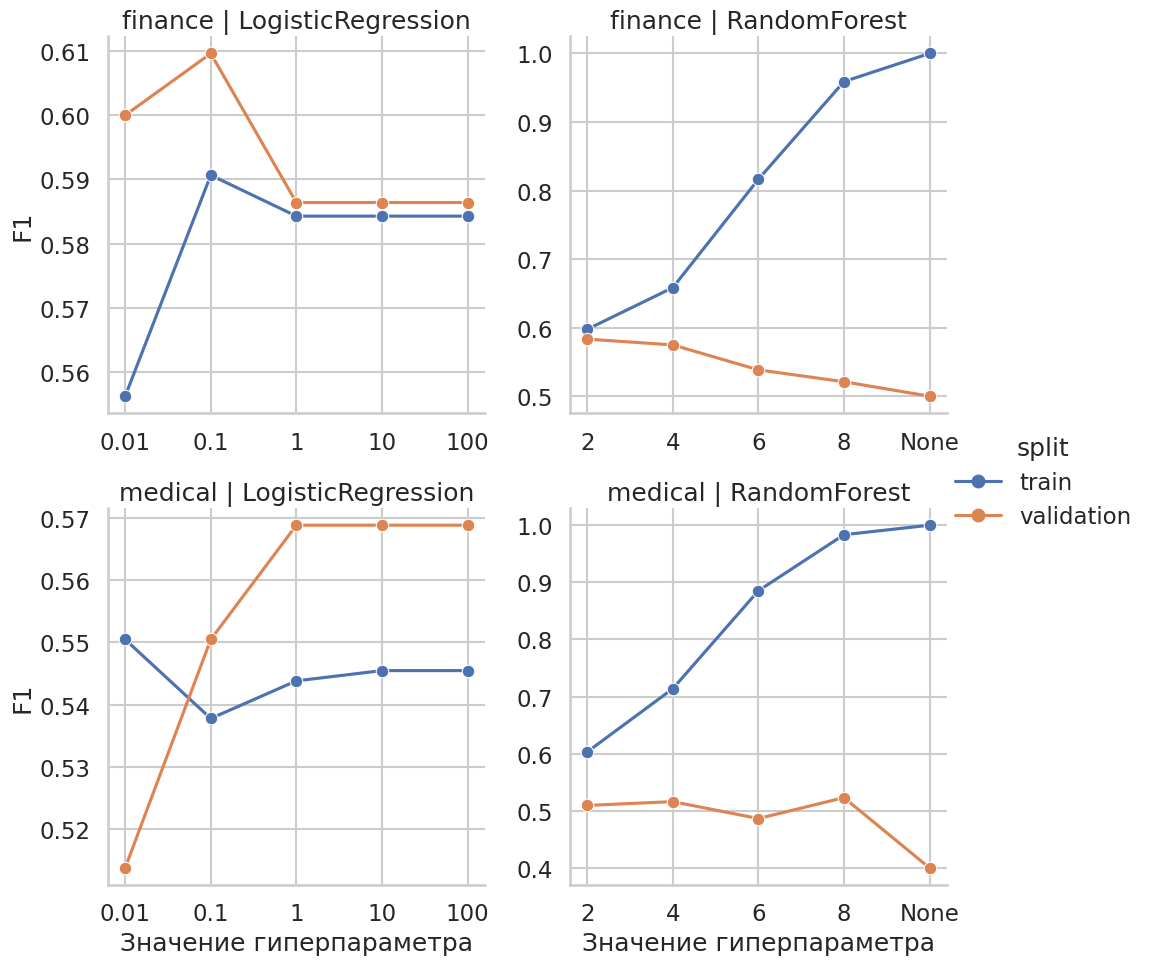

In [6]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# Логика для новичка: этот блок лучше читать сверху вниз как мини-сценарий шага.
plot_df = validation_curve_results.copy()

grid = sns.relplot(
    data=plot_df,
    x='param_value',
    y='f1',
    hue='split',
    col='model',
    row='dataset',
    kind='line',
    marker='o',
    facet_kws={'sharey': False, 'sharex': False},
)
grid.set_axis_labels('Значение гиперпараметра', 'F1')
grid.set_titles(row_template='{row_name}', col_template='{col_name}')
# Строим визуализацию и проверяем интерпретируемость результата.
plt.show()

### Как интерпретировать результат
- Validation curves отвечают на вопрос: что происходит с качеством, когда мы усиливаем или ослабляем модель по одному параметру.
- Читать их нужно начиная с линии `validation`: train-линия полезна как контекст, но не как главный критерий.
- Если train растет, а validation почти не улучшается или падает, это учебный признак переусложнения модели.

### Пример вывода по шагу
- Для `LogisticRegression` слишком маленький `C` обычно делает модель слишком жестко регуляризованной, а очень большие значения уже не всегда дают пользу на validation.
- Для `RandomForest` рост `max_depth` может повышать train-качество быстрее, чем validation-качество, и это хороший визуальный пример overfitting.
- В отчет здесь стоит переносить не только «лучшее значение параметра», но и качественное описание: где модель была слишком слабой, а где слишком сложной.

### Проверь себя
- В `validation_curve_results` есть оба split: `train` и `validation`.
- Для каждой пары `dataset + model` используется ровно тот набор признаков (feature set), который выбран в `model_feature_set_decisions`.
- Вы можете назвать хотя бы один параметр, при котором validation выглядит лучше всего.
- Вы не делаете выводы только по линии `train`.

## Шаг 5. Экспорт обязательных артефактов

### Что делаем
- проверяем контракты таблиц;
- сохраняем 3 обязательных CSV в `outputs/`;
- фиксируем, что notebook 1 теперь завершен и notebook 2 может читать его результаты.

### Почему это важно
- второй ноутбук не должен зависеть от памяти текущей сессии;
- явные артефакты делают workflow проверяемым и воспроизводимым;
- экспорт завершает student-facing маршрут notebook 1.

### Что уже готово на входе
- `generalization_audit`;
- `model_feature_set_decisions`;
- `validation_curve_results`.

### Что должно получиться на выходе
- три CSV в `outputs/` с корректными колонками;
- готовый вход для notebook 2.

Переход к следующему шагу: зафиксируйте выводы текущего шага и используйте их как вход следующего блока.


In [7]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Логика для новичка: этот блок лучше читать сверху вниз как мини-сценарий шага.
required_generalization_columns = {
    'dataset',
    'feature_set',
    'model',
    'split',
    'accuracy',
    'f1',
    'roc_auc',
    'fit_time_sec',
}
required_decision_columns = set(lab.MODEL_FEATURE_SET_DECISION_COLUMNS)
required_curve_columns = {
    'dataset',
    'feature_set',
    'model',
    'hyperparameter',
    'param_value',
    'split',
    'accuracy',
    'f1',
    'roc_auc',
}

# Проверяем обязательное условие корректности шага.
assert set(generalization_audit.columns) == required_generalization_columns
assert set(model_feature_set_decisions.columns) == required_decision_columns
assert set(validation_curve_results.columns) == required_curve_columns

# Сохраняем таблицу артефакта в CSV.
generalization_audit.to_csv(OUTPUT_DIR / 'generalization_audit.csv', index=False)
model_feature_set_decisions.to_csv(OUTPUT_DIR / 'model_feature_set_decisions.csv', index=False)
validation_curve_results.to_csv(OUTPUT_DIR / 'validation_curve_results.csv', index=False)

print('Сохранены outputs/generalization_audit.csv, outputs/model_feature_set_decisions.csv и outputs/validation_curve_results.csv')

Сохранены outputs/generalization_audit.csv, outputs/model_feature_set_decisions.csv и outputs/validation_curve_results.csv


### Как интерпретировать результат
- Экспорт завершает notebook 1 как самостоятельный этап: дальше второй ноутбук должен читать только явные CSV, а не внутренние переменные этой сессии.
- Это важная часть честного workflow: отделить baseline-audit и выбор набор признаков (feature set) от дальнейшего тюнинга.
- Если артефакты сохранены, разделы `2`, `2.1`, `3` и `4` отчета уже полностью обеспечены данными.

### Пример вывода по шагу
- Notebook 1 заканчивается не просто таблицами на экране, а воспроизводимым набором артефактов для следующего этапа.
- Это снижает риск скрытого состояния между ноутбуками и делает весь маршрут проверяемым для преподавателя.
- На этом этапе важно не только сохранить CSV, но и понять, что `test` все еще остается нетронутым holdout.


### Проверь себя
- В `outputs/` лежат все 3 CSV из notebook 1.
- Артефакты достаточно полны, чтобы notebook 2 стартовал без скрытого пересчета.
- Все ключевые выводы notebook 1 можно уже переносить в отчет.
- `test` на этом этапе не использовался ни разу.
